In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**DATA**

In [ ]:
df = pd.read_csv('/data.csv')

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.shape

(569, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.drop("Unnamed: 32", axis=1, inplace=True)

In [ ]:
df.drop('id',axis=1, inplace=True)

DATA **VISUALIZATION**

/tmp/ipykernel_1587/1172780693.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="diagnosis", data=df, palette='magma')


<Axes: xlabel='diagnosis', ylabel='count'>

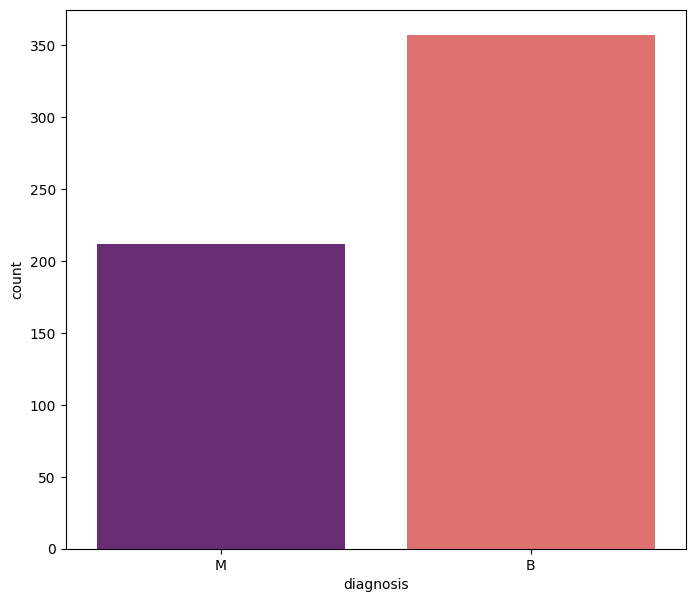

In [ ]:
plt.figure(figsize = (8,7))
sns.countplot(x="diagnosis", data=df, palette='magma')

<Axes: >

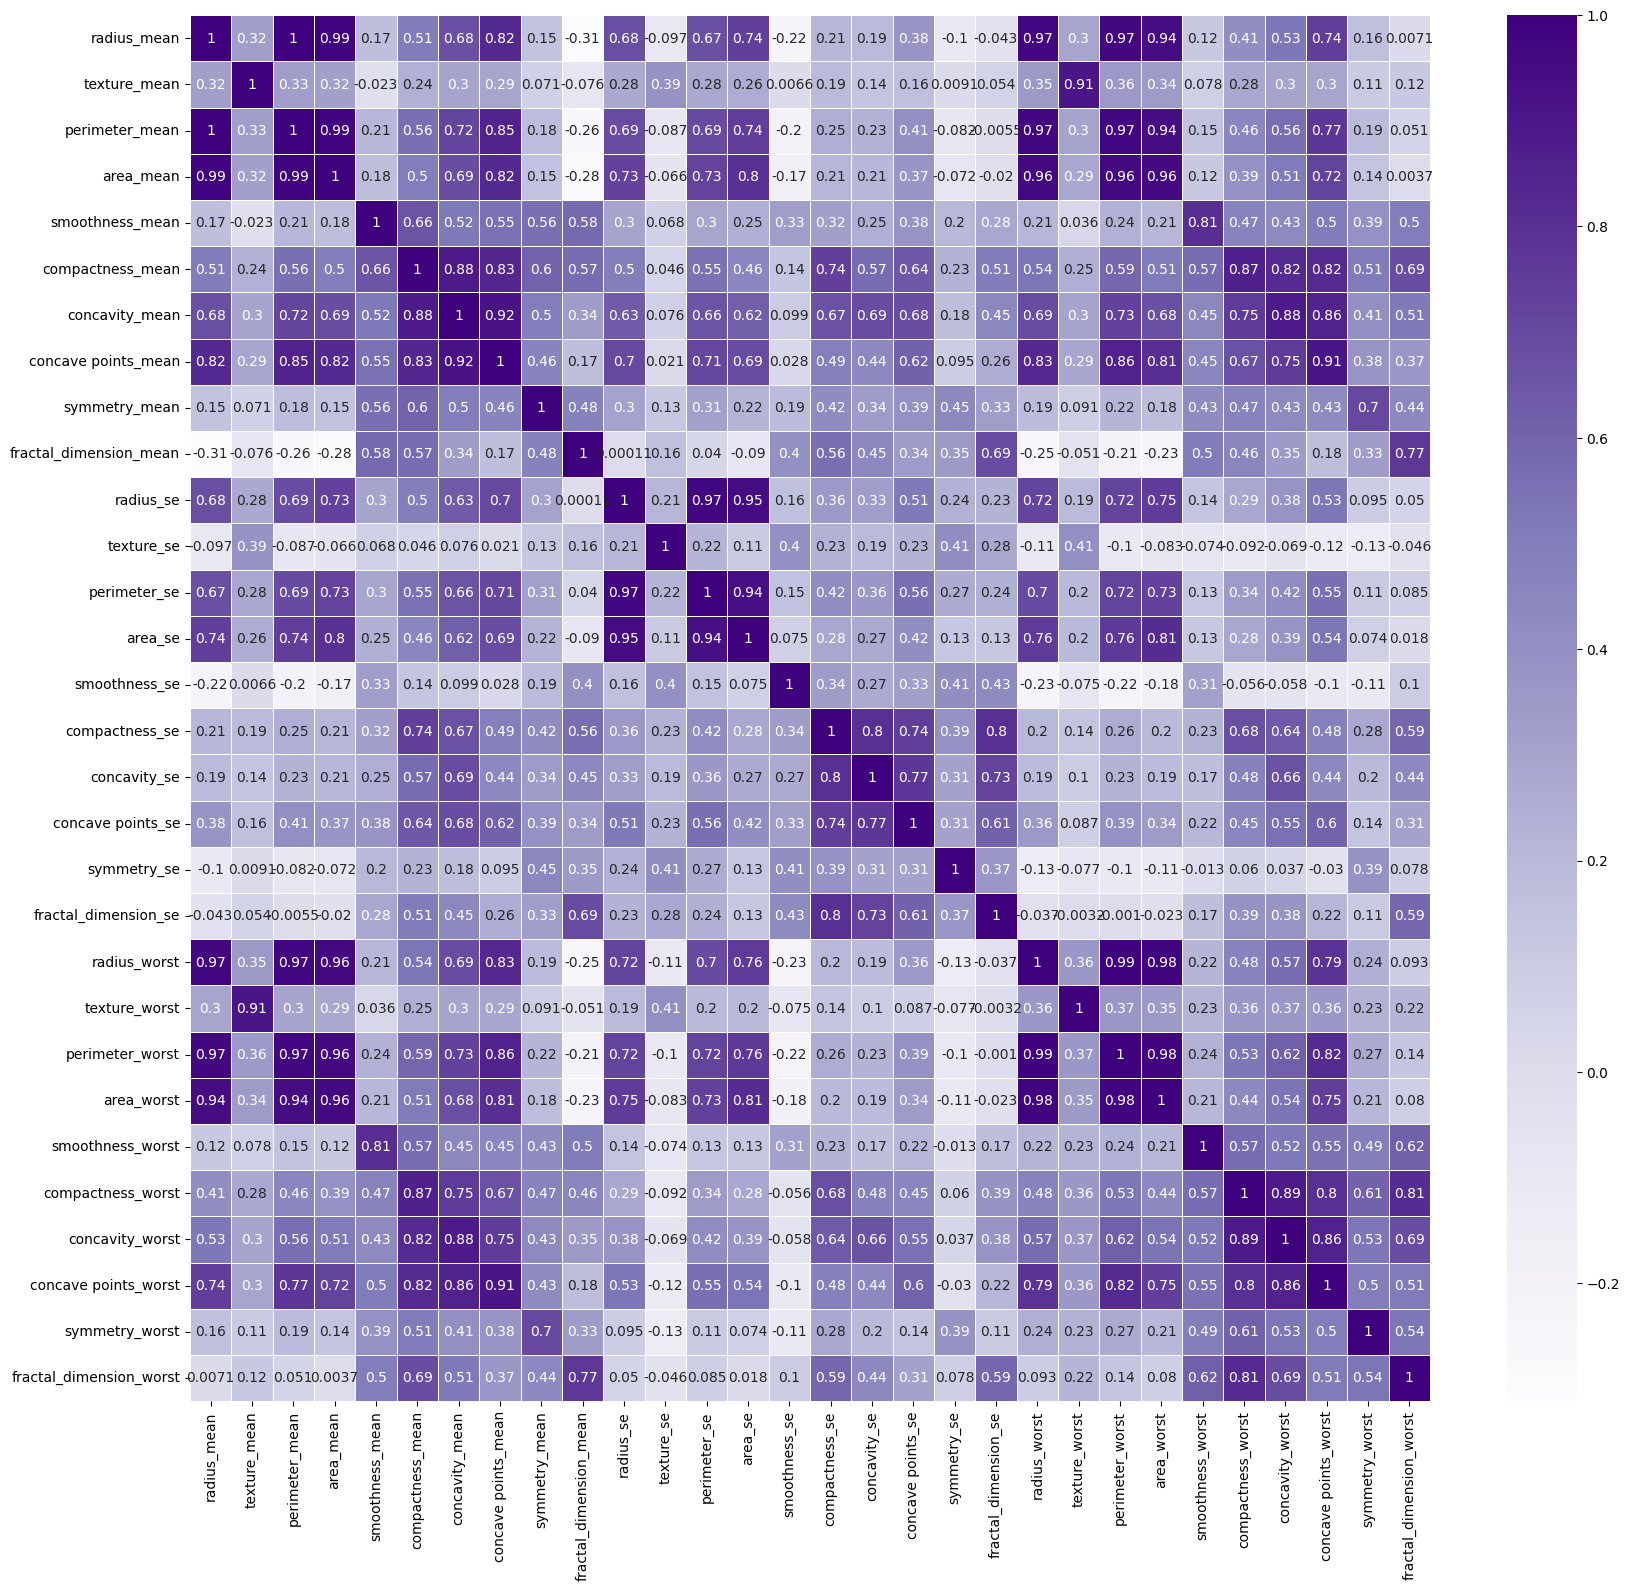

In [ ]:
# heatmap
plt.figure(figsize=(20,18))
sns.heatmap(df.drop('diagnosis', axis=1).corr(),
            annot=True, linewidths=0.5, cmap="Purples")

### radius_mean, perimeter_mean, area_mean Correlation: ≈0.99-1.00
For a roughly circular nucleus, perimeter (P=2πr) and area (A=πr
2) are direct functions of the radius.



compactness_mean, concavity_mean, concave points_mean
Correlation: ≈0.83-0.92**

DATA **PREPROCESSING AND TRAINING**

In [ ]:
df['diagnosis']=df['diagnosis'].map({'B':0,'M':1})

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('diagnosis', axis=1),df['diagnosis'],test_size=0.2,
                                                    random_state=42)

print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape)

Shape of training set: (398, 30)
Shape of test set: (171, 30)


In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.fit_transform(X_test)

If we do not scale the data:

Dominance: A feature with a large range (e.g., area from 143 to 2501) will contribute exponentially more to the distance sum than a feature with a small range (e.g., smoothness from 0.05 to 0.16).

Bias: The algorithm will "ignore" the smaller-scale features, even if they are more predictive of cancer, effectively treating the model as if only the high-magnitude features exist.

Convergence: For algorithms using gradient descent (like Logistic Regression or Neural Networks), disparate scales cause the cost function to look like a long, narrow valley, making convergence much slower or even impossible.

Standardization (Z-Score Normalization)

This transforms the data so that it has a mean of 0 and a standard deviation of 1. It is preferred when the data follows a Gaussian distribution or when using algorithms like PCA and SVM.

Formula: z=
x-μ/σ


Result: All features now exist on a common scale (mostly between -1 and 1), ensuring no single feature dominates.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
error_rate = []

for i in range(1,42):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

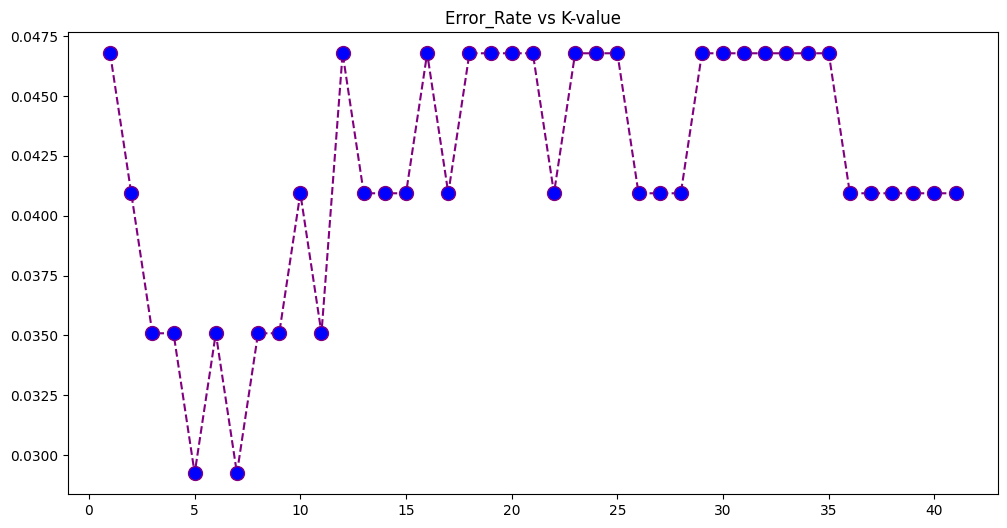

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(range(1,42), error_rate, color='purple', linestyle="--",
         marker='o', markersize=10, markerfacecolor='b')
plt.title('Error_Rate vs K-value')
plt.show()

In [ ]:
nn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)
predictions2 = knn.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_test, predictions2))
print("\n")
print(classification_report(y_test, predictions2))

[[108   0]
 [  7  56]]


              precision    recall  f1-score   support

           0       0.94      1.00      0.97       108
           1       1.00      0.89      0.94        63

    accuracy                           0.96       171
   macro avg       0.97      0.94      0.95       171
weighted avg       0.96      0.96      0.96       171



In [ ]:
knn_model_acc = accuracy_score(y_test, predictions2)
print("Accuracy of K Neighbors Classifier Model is: ", knn_model_acc)

Accuracy of K Neighbors Classifier Model is:  0.9590643274853801


Accuracy is often misleading in medical diagnosis because it treats all errors equally; in cancer detection, a False Negative (missing a disease) is far more dangerous than a False Positive (a false alarm).

Recall is the most critical metric here as it measures the ability to catch every actual case of cancer, while Precision ensures we don't overwhelm healthy patients with unnecessary stress.

 The F1-score acts as a vital balance between the two, providing a reliable measure of a model's performance even when the dataset is imbalanced.